<a href="https://colab.research.google.com/github/priyalpatil31/AML_Priyal_Patil_19/blob/main/EXP_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
   InvoiceNo StockCode                         Description  Quantity  \
0     536365    85123A  WHITE HANGING HEART T-LIGHT HOLDER         6   
1     536367     84879       ASSORTED COLOUR BIRD ORNAMENT        32   
2     536371     22086     PAPER CHAIN KIT 50'S CHRISTMAS         80   
3     536373    85123A  WHITE HANGING HEART T-LIGHT HOLDER         6   
4     536375    85123A  WHITE HANGING HEART T-LIGHT HOLDER         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55       17850  United Kingdom  
1 2010-12-01 08:34:00       1.69       13047  United Kingdom  
2 2010-12-01 09:00:00       2.55       13748  United Kingdom  
3 2010-12-01 09:02:00       2.55       17850  United Kingdom  
4 2010-12-01 09:32:00       2.55       17850  United Kingdom  

Missing Values
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int6

/tmp/ipykernel_2203/448488107.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


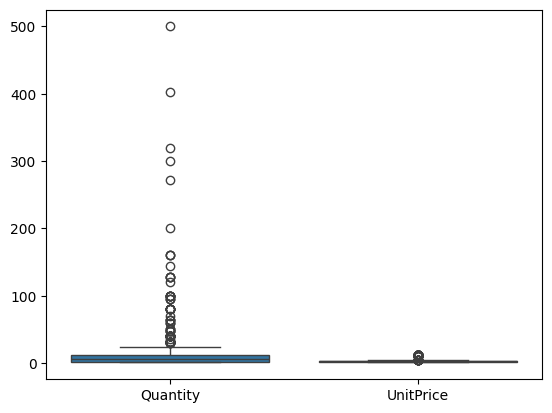

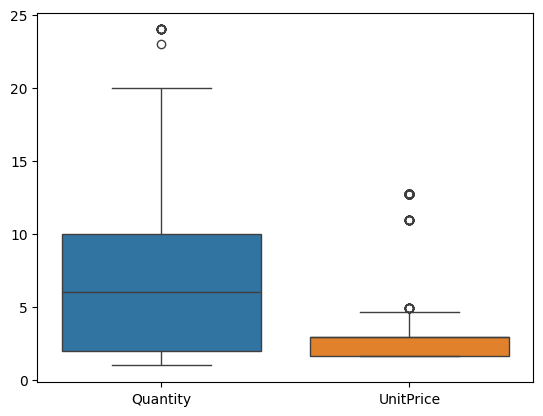

TypeError: Encoders require their input argument must be uniformly strings or numbers. Got ['int', 'str']

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

path = "/content/drive/MyDrive/Online_Retail_Small.xlsx"

df = pd.read_excel(path)

print(df.head())

print("\nMissing Values")
print(df.isnull().sum())

df.fillna(df.mean(numeric_only=True), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing Values After Handling")
print(df.isnull().sum())

sns.boxplot(data=df[['Quantity','UnitPrice']])
plt.show()

Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Quantity'] >= lower) & (df['Quantity'] <= upper)]

sns.boxplot(data=df[['Quantity','UnitPrice']])
plt.show()

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print("\nBefore Scaling")
print(df.head())

scaler = StandardScaler()

df[['Quantity','UnitPrice']] = scaler.fit_transform(df[['Quantity','UnitPrice']])

print("\nAfter Scaling")
print(df.head())

print("\nEDA")

print(df.describe())

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()